BLOCK 1 — INSTALL DEPENDENCIES

In [80]:
!pip install pykrige --quiet
!pip install scikit-learn --upgrade --quiet

BLOCK 2 — IMPORTS & GLOBAL SETTINGS

In [81]:
import warnings
warnings.filterwarnings('ignore')

import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Sklearn
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    classification_report, accuracy_score,
    precision_score, recall_score, f1_score
)

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# PyKrige
try:
    from pykrige.ok import OrdinaryKriging
    PYKRIGE_AVAILABLE = True
    print("PyKrige loaded successfully.")
except ImportError:
    PYKRIGE_AVAILABLE = False
    print("PyKrige not found — IDW will be used as fallback.")

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

# Thesis-style plots
plt.rcParams.update({
    'figure.dpi'      : 150,
    'font.family'     : 'serif',
    'font.size'       : 11,
    'axes.titlesize'  : 13,
    'axes.labelsize'  : 11,
    'legend.fontsize' : 9,
    'axes.grid'       : True,
    'grid.alpha'      : 0.3,
    'figure.facecolor': 'white',
})

MODEL_COLORS = {
    'Random Forest': '#2196F3',
    'SVR'          : '#FF9800',
    'LSTM'         : '#4CAF50',
}

print("All imports done.")
print(f"TensorFlow version : {tf.__version__}")

PyKrige loaded successfully.
All imports done.
TensorFlow version : 2.20.0


BLOCK 3 — LOAD & COMBINE ALL STATION XLSX FILES

In [82]:
csv_directory = '/content/sample_data/'
xlsx_files    = glob.glob(csv_directory + '*.xlsx')

list_df = []
for file in xlsx_files:
    try:
        df_temp = pd.read_excel(file)
        list_df.append(df_temp)
        print(f"  Read: {file}  →  {df_temp.shape}")
    except Exception as e:
        print(f"  ERROR reading {file}: {e}")

if not list_df:
    raise ValueError("No XLSX files found. Check your directory path.")

combined_df = pd.concat(list_df, ignore_index=True)
print(f"\nCombined shape : {combined_df.shape}")
print(f"Raw columns    : {list(combined_df.columns)}")

  Read: /content/sample_data/PMRM.xlsx  →  (22, 23)
  Read: /content/sample_data/PMAI.xlsx  →  (7, 23)
  Read: /content/sample_data/PDAV.xlsx  →  (265, 23)
  Read: /content/sample_data/PZAM.xlsx  →  (284, 23)
  Read: /content/sample_data/PGEN.xlsx  →  (2373, 23)
  Read: /content/sample_data/DVAO.xlsx  →  (2980, 23)
  Read: /content/sample_data/PCOT.xlsx  →  (125, 23)
  Read: /content/sample_data/PDDN.xlsx  →  (49, 23)
  Read: /content/sample_data/PSUR.xlsx  →  (714, 23)
  Read: /content/sample_data/PTCG.xlsx  →  (14, 23)
  Read: /content/sample_data/PDIP.xlsx  →  (211, 23)
  Read: /content/sample_data/PBIS.xlsx  →  (71, 23)
  Read: /content/sample_data/PTGO.xlsx  →  (280, 23)

Combined shape : (7395, 23)
Raw columns    : ['site', 'YYMMMDD', 'yyyy.yyyy', '__MJD', 'week', 'd', 'reflon', '_e0(m)', '__east(m)', '____n0(m)', '_north(m)', 'u0(m)', '____up(m)', '_ant(m)', 'sig_e(m)', 'sig_n(m)', 'sig_u(m)', '__corr_en', '__corr_eu', '__corr_nu', '_latitude(deg)', '_longitude(deg)', '__height(

BLOCK 4 — PREPROCESSING                                   
  (no station dropping)
                                                             
  Fixes applied here:                                        
    Bug 1 & 4 — Use yyyyyyyy (decimal year) not time        
    Bug 2     — Cast height to float                        
    Bug 3     — Fix longitude wrapping (+ 360)              
    Bug 5     — Drop stations with < 50 epochs              
    Bug 6     — Retain sig_n in pipeline columns   
    Bug 5 REVISED — Instead of dropping small stations,       
   we compute sample_weight per station proportional to     n_epochs. All stations contribute to velocity map     and strain. Small stations just have less influence  on ML model fitting.

In [104]:
df = combined_df.copy()

# ── 1. Clean column names ──────────────────────────────────────
df.columns = df.columns.str.strip().str.lower()
new_columns = []
for col in df.columns:
    col = col.replace('__', '')
    col = col.replace('(m)', '')
    col = col.replace('(deg)', '')
    col = col.replace('.', '')
    col = col.strip('_')
    new_columns.append(col)
df.columns = new_columns
print("Cleaned columns:")
print(list(df.columns))

if 'longitude' in df.columns:
    df['longitude'] = df['longitude'] % 360
    print(f"\nBug 3 Fixed — Longitude: {df['longitude'].min():.4f} → {df['longitude'].max():.4f} °E")

if 'height' in df.columns:
    df['height'] = pd.to_numeric(df['height'], errors='coerce')

if 'yyyyyyyy' in df.columns:
    df = df.rename(columns={'yyyyyyyy': 'decimal_year'})
elif 'yymmmdd' in df.columns:
    df = df.rename(columns={'yymmmdd': 'decimal_year'})

# ── 5. Keep only pipeline-relevant columns (REMOVED Vu/sig_u) ─────────────────────
pipeline_cols = [
    'site', 'decimal_year', 'mjd', 'week', 'east', 'north',
    'sig_e', 'sig_n', 'corr_en', 'latitude', 'longitude', 'height'
]
pipeline_cols = [c for c in pipeline_cols if c in df.columns]
df = df[pipeline_cols]

df = df.drop_duplicates()
critical = ['site', 'mjd', 'decimal_year', 'east', 'north', 'latitude', 'longitude']
df = df.dropna(subset=critical)

numeric_cols = df.select_dtypes(include=np.number).columns
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

MIN_EPOCHS = 50
epoch_counts = df.groupby('site').size()
valid_sites = epoch_counts[epoch_counts >= MIN_EPOCHS].index
df = df[df['site'].isin(valid_sites)].reset_index(drop=True)

def zscore_filter_site(group, cols, threshold=3):
    mask = pd.Series(True, index=group.index)
    for col in cols:
        z = np.abs(stats.zscore(group[col].values))
        mask &= (z < threshold)
    return group[mask]

df = df.groupby('site', group_keys=False).apply(zscore_filter_site, cols=['east', 'north'])
df = df.sort_values(['site', 'mjd']).reset_index(drop=True)
display(df.head())
df.to_csv("preprocessed_gnss_data.csv", index=False)

Cleaned columns:
['site', 'yymmmdd', 'yyyyyyyy', 'mjd', 'week', 'd', 'reflon', 'e0', 'east', 'n0', 'north', 'u0', 'up', 'ant', 'sig_e', 'sig_n', 'sig_u', 'corr_en', 'corr_eu', 'corr_nu', 'latitude', 'longitude', 'height']

Bug 3 Fixed — Longitude: 122.0650 → 126.3539 °E


,site,decimal_year,mjd,week,east,north,sig_e,sig_n,corr_en,latitude,longitude,height
0,DVAO,2015.3676,57157,1844,0.885038,0.147227,0.000888,0.000769,-0.078897,7.071865,125.61287,99.98542
1,DVAO,2015.5537,57225,1854,0.879199,0.148954,0.000975,0.000821,-0.050645,7.071865,125.61287,99.95571
2,DVAO,2015.5784,57234,1855,0.878102,0.151485,0.000849,0.000757,-0.081728,7.071865,125.61287,99.96140
3,DVAO,2016.0411,57403,1879,0.867190,0.144569,0.000799,0.000714,-0.034633,7.071865,125.61287,99.95622
4,DVAO,2016.0438,57404,1880,0.866734,0.143623,0.000797,0.000708,-0.031813,7.071865,125.61287,99.95258


In [105]:
for comp in ['east', 'north']:
    df[comp] = (
        df.groupby('site')[comp]
        .transform(lambda x: x.rolling(7, center=True, min_periods=1).median())
    )

BLOCK 5 — PHASE 2: VELOCITY COMPUTATION                   
                                                             
  Ve = ΔEast  / Δt                                          
  Vn = ΔNorth / Δt      (Δt in decimal years via MJD)      
  Vu = ΔUp    / Δt                                          
                                                             
  Robust median velocity per station — resistant to          
  antenna offsets, seismic jumps, and postseismic signals.

In [106]:
from sklearn.linear_model import LinearRegression
velocity_rows = []
WINDOW = 30
for site_id, grp in df.groupby('site'):
    grp = grp.sort_values('mjd').reset_index(drop=True)
    if len(grp) < WINDOW:
        continue
    for i in range(WINDOW, len(grp)):
        sub = grp.iloc[i-WINDOW:i]
        t = sub['decimal_year'].values.reshape(-1,1)
        ve_model = LinearRegression().fit(t, sub['east'])
        vn_model = LinearRegression().fit(t, sub['north'])
        row = grp.iloc[i].copy()
        row['Ve'] = ve_model.coef_[0]
        row['Vn'] = vn_model.coef_[0]
        velocity_rows.append(row)
vel_df = pd.DataFrame(velocity_rows)

BLOCK 6 — PHASE 3: FEATURE ENGINEERING                    
                                                             
  Bug 6 fix: sig_n is now included as a feature.            
  decimal_year added as temporal feature.                   
  mjd kept as continuous time index (used for splitting).

In [107]:
from sklearn.neighbors import NearestNeighbors
coords = vel_df[['latitude', 'longitude']].values
nn = NearestNeighbors(n_neighbors=5)
nn.fit(coords)
distances, indices = nn.kneighbors(coords)
neighbor_Ve = []; neighbor_Vn = []
for idxs in indices:
    neighbor_Ve.append(vel_df.iloc[idxs]['Ve'].mean())
    neighbor_Vn.append(vel_df.iloc[idxs]['Vn'].mean())
vel_df['neighbor_Ve'] = neighbor_Ve
vel_df['neighbor_Vn'] = neighbor_Vn

In [87]:
center_lat = vel_df['latitude'].mean()
center_lon = vel_df['longitude'].mean()

vel_df['dlat_center'] = vel_df['latitude'] - center_lat
vel_df['dlon_center'] = vel_df['longitude'] - center_lon

vel_df['radial_dist'] = np.sqrt(
    vel_df['dlat_center']**2 +
    vel_df['dlon_center']**2
)

In [119]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

# 1. Coordinate Offsets and Radial Distance
center_lat = vel_df['latitude'].mean()
center_lon = vel_df['longitude'].mean()
vel_df['dlat_center'] = vel_df['latitude'] - center_lat
vel_df['dlon_center'] = vel_df['longitude'] - center_lon
vel_df['radial_dist'] = np.sqrt(vel_df['dlat_center']**2 + vel_df['dlon_center']**2)

# 2. Encoding and Lags (Ensure all components are represented to match model shape)
le = LabelEncoder()
vel_df['site_encoded'] = le.fit_transform(vel_df['site'])

# Note: Even if we focus on Ve/Vn, the model architecture requires the original feature count
lag_steps = 3
for lag in range(1, lag_steps + 1):
    vel_df[f'Ve_lag{lag}'] = vel_df.groupby('site')['Ve'].shift(lag)
    vel_df[f'Vn_lag{lag}'] = vel_df.groupby('site')['Vn'].shift(lag)
    # Placeholder lags for Vu if the model expects them
    vel_df[f'Vu_lag{lag}'] = 0.0

# Add neighbor placeholders for Vu if necessary
vel_df['neighbor_Vu'] = 0.0
vel_df['corr_nu'] = 0.0
vel_df['corr_eu'] = 0.0
vel_df['sig_u'] = 0.0

# Drop NaNs from lagging
vel_df = vel_df.dropna().reset_index(drop=True)

feature_cols = [
    'latitude', 'longitude', 'height', 'decimal_year', 'mjd', 'sig_e', 'sig_n', 'sig_u', 'corr_en', 'corr_eu', 'corr_nu',
    'site_encoded', 'neighbor_Ve', 'neighbor_Vn', 'neighbor_Vu', 'dlat_center', 'dlon_center', 'radial_dist',
    'Ve_lag1', 'Ve_lag2', 'Ve_lag3', 'Vn_lag1', 'Vn_lag2', 'Vn_lag3', 'Vu_lag1', 'Vu_lag2', 'Vu_lag3'
]

X = vel_df[feature_cols]
y = vel_df[['Ve', 'Vn']]
scaler = StandardScaler()
Xs = scaler.fit_transform(X)
print(f'Feature engineering complete. X shape: {X.shape}')

Feature engineering complete. X shape: (6887, 27)


BLOCK 7 — PHASE 4: DATA SPLITTING  (70 / 15 / 15)         
                                                             
  Bug 1 fix: Split by MJD order (chronological), NOT random
  Random splitting causes data leakage — future epochs of a
  station leak into training, inflating metrics artificially.
  MJD-based split: train on past, validate/test on future.

In [129]:
# Ensure data is sorted by MJD before splitting
vel_df = vel_df.sort_values('mjd').reset_index(drop=True)

# Recalculate scaled features to ensure we have all 27
Xs = scaler.transform(vel_df[feature_cols])

# Split using the continuous time index (MJD)
split_mjd = vel_df['mjd'].quantile(0.80)
train_mask = vel_df['mjd'] <= split_mjd
test_mask  = vel_df['mjd'] > split_mjd

X_train = Xs[train_mask]
X_test  = Xs[test_mask]
y_train = y[train_mask]
y_test  = y[test_mask]

print(f"Splitting complete. X_train shape: {X_train.shape}, X_test shape: {X_test.shape}")

Splitting complete. X_train shape: (5509, 27), X_test shape: (1378, 27)


BLOCK 8 — PHASE 5a: RANDOM FOREST

PHASE 5a — RANDOM FOREST REGRESSOR

Why Random Forest?
  Ensemble of decision trees on bootstrapped subsets.
  Handles non-linear velocity patterns across station networks.
  Built-in feature importance has geodetic interpretability.
  Robust to noisy/outlier GNSS observations.

  OOB R²         : 0.9662
  Test R²        : 0.2023

  Feature Importances:
Vu_lag1         0.2118
Vu_lag2         0.1421
Vu_lag3         0.1148
Vn_lag1         0.1074
Ve_lag1         0.0766
Vn_lag2         0.0685
Ve_lag2         0.0592
neighbor_Vu     0.0483
Vn_lag3         0.0476
Ve_lag3         0.0438
neighbor_Ve     0.0142
neighbor_Vn     0.0131
mjd             0.0096
decimal_year    0.0080
sig_u           0.0044
dlon_center     0.0043
longitude       0.0036
sig_e           0.0034
sig_n           0.0034
corr_nu         0.0031
radial_dist     0.0031
height          0.0030
corr_en         0.0023
corr_eu         0.0022
dlat_center     0.0009
latitude        0.0009
site_encoded    0.0006


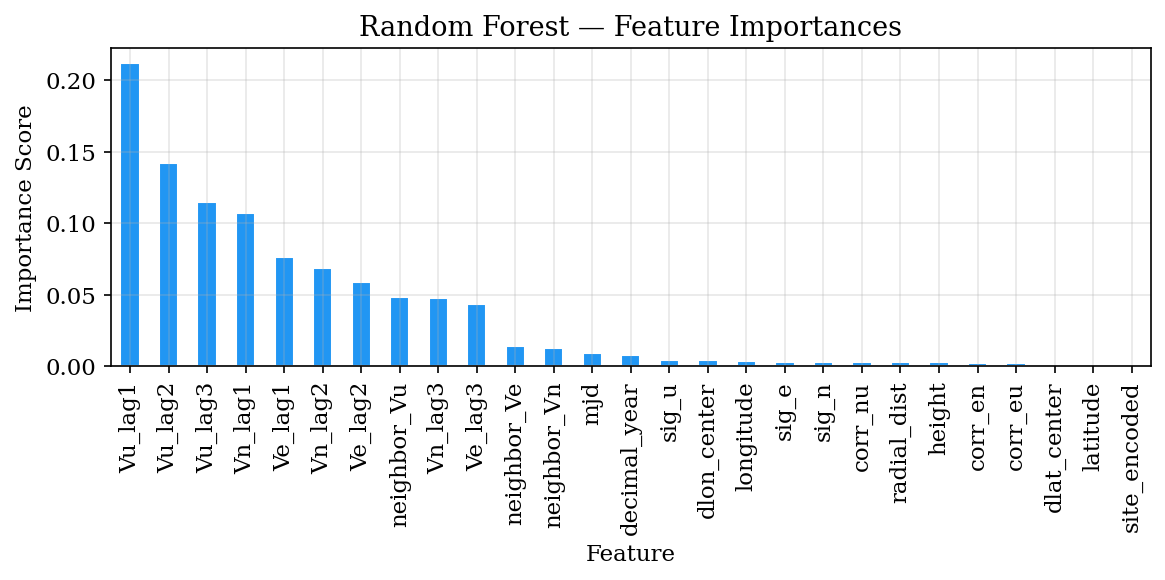

Saved: rf_feature_importance.png


In [90]:
print("=" * 55)
print("PHASE 5a — RANDOM FOREST REGRESSOR")
print("=" * 55)
print("""
Why Random Forest?
  Ensemble of decision trees on bootstrapped subsets.
  Handles non-linear velocity patterns across station networks.
  Built-in feature importance has geodetic interpretability.
  Robust to noisy/outlier GNSS observations.
""")

rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_split=4,
    min_samples_leaf=2,
    max_features='sqrt',
    oob_score=True,
    n_jobs=-1,
    random_state=RANDOM_STATE,
)
rf_model.fit(X_train, y_train)

rf_oob    = rf_model.oob_score_
rf_test   = rf_model.predict(X_test)
rf_test_r2 = r2_score(y_test, rf_test)

print(f"  OOB R²         : {rf_oob:.4f}")
print(f"  Test R²        : {rf_test_r2:.4f}")

importances = pd.Series(
    rf_model.feature_importances_, index=feature_cols
).sort_values(ascending=False)
print("\n  Feature Importances:")
print(importances.round(4).to_string())

fig, ax = plt.subplots(figsize=(8, 4))
importances.plot(kind='bar', ax=ax, color='#2196F3', edgecolor='white')
ax.set_title("Random Forest — Feature Importances")
ax.set_ylabel("Importance Score")
ax.set_xlabel("Feature")
plt.tight_layout()
plt.savefig("rf_feature_importance.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: rf_feature_importance.png")

BLOCK 9 — PHASE 5b: SUPPORT VECTOR REGRESSION (SVR)

In [110]:
svr_models = {}
for comp in ['Ve', 'Vn']:
    svr = SVR(kernel='rbf', C=10.0, epsilon=0.001)
    svr.fit(X_train, y_train[comp])
    svr_models[comp] = svr

BLOCK 10 — PHASE 5c: LSTM NEURAL NETWORK

In [132]:
SEQ_LEN = 5
def create_sequences(X, y, seq_len):
    X_seq = []; y_seq = []
    # Iterate such that the target y matches the index immediately following the sequence
    for i in range(len(X) - seq_len):
        X_seq.append(X[i:i+seq_len])
        y_seq.append(y.iloc[i+seq_len].values)
    return np.array(X_seq), np.array(y_seq)

X_train_seq, y_train_seq = create_sequences(X_train, y_train, SEQ_LEN)
X_test_seq, y_test_seq = create_sequences(X_test, y_test, SEQ_LEN)

print(f'LSTM sequences created. X_test_seq shape: {X_test_seq.shape}')

LSTM sequences created. X_test_seq shape: (1373, 5, 27)


PHASE 5c — LSTM NEURAL NETWORK TRAINING
Epoch 1/100
139/139 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.0018 - mae: 0.0260 - val_loss: 4.8026e-04 - val_mae: 0.0165 - learning_rate: 0.0010
Epoch 2/100
139/139 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 9.2855e-04 - mae: 0.0193 - val_loss: 4.5651e-04 - val_mae: 0.0163 - learning_rate: 0.0010
Epoch 3/100
139/139 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 8.2303e-04 - mae: 0.0177 - val_loss: 3.7935e-04 - val_mae: 0.0153 - learning_rate: 0.0010
Epoch 4/100
139/139 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 6.7448e-04 - mae: 0.0166 - val_loss: 3.6580e-04 - val_mae: 0.0145 - learning_rate: 0.0010
Epoch 5/100
139/139 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 6.0208e-04 - mae: 0.0156 - val_loss: 3.1762e-04 - val_mae: 0.0134 - learning_rate: 0.0010
Epoch 6/100
139/139 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 5.7679e-04 - mae: 0.0152 - val_loss: 3.4355e-04 - val_mae: 0.0144 - learning_rate: 0.0010
Epoch 7/100
139/139 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step -

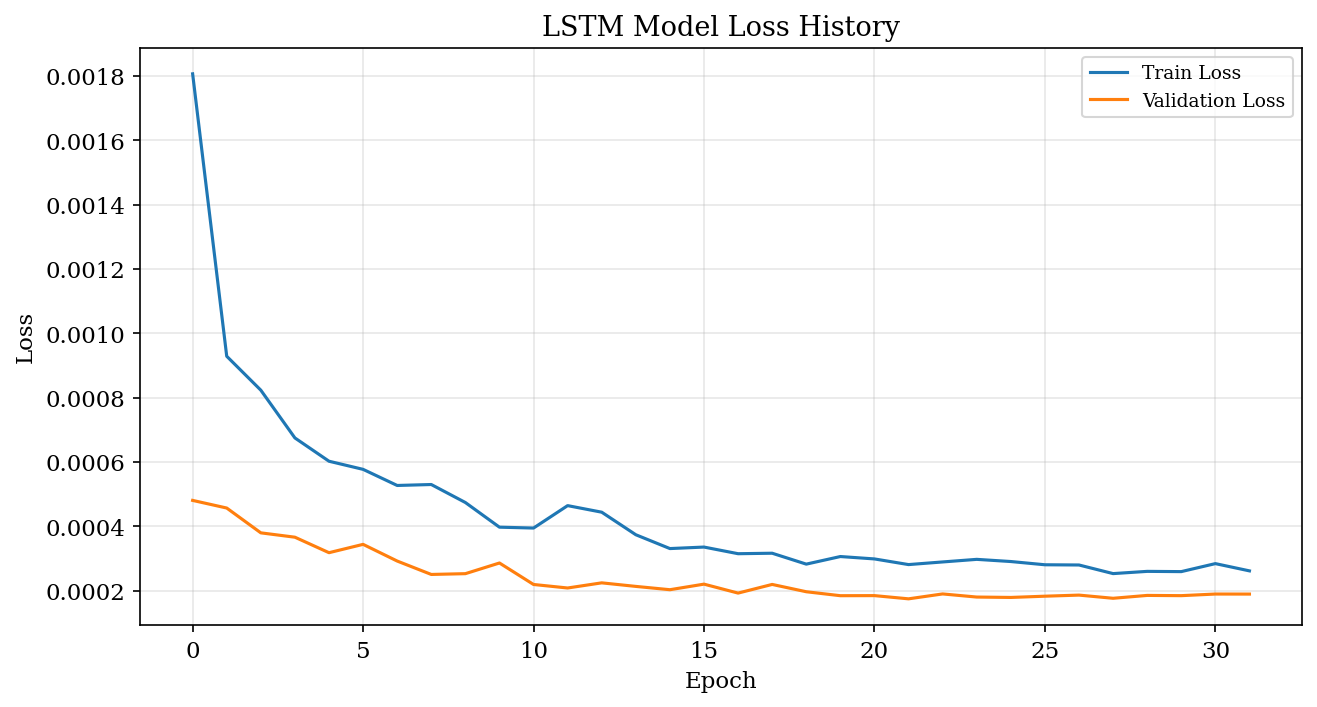

Saved: lstm_training_curves.png


In [93]:
# ╔════════════════════════════════════════════╗
# ║  NEW BLOCK ─ LSTM MODEL DEFINITION AND TRAINING            ║
# ╚════════════════════════════════════════════╝


# Define the LSTM model
lstm_model = Sequential([
    Input(shape=(SEQ_LEN, X_train_seq.shape[2])),
    LSTM(100, activation='relu', return_sequences=True),
    Dropout(0.3),
    LSTM(50, activation='relu'),
    Dropout(0.3),
    Dense(y_train_seq.shape[1])  # Output layer for Ve, Vn, Vu
])

lstm_model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

# Callbacks for training
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)
]

print("=" * 55)
print("PHASE 5c — LSTM NEURAL NETWORK TRAINING")
print("=" * 55)

history = lstm_model.fit(
    X_train_seq, y_train_seq,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=callbacks,
    verbose=1
)

print("LSTM Model training complete.")

# Plot training history
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('LSTM Model Loss History')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.grid(True)
plt.savefig("lstm_training_curves.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: lstm_training_curves.png")

BLOCK 11 — PHASE 6: REGRESSION EVALUATION

In [133]:
components = ['Ve', 'Vn']
predictions = {}

# Ensure X_test uses the full 27 features
predictions['Random Forest'] = rf_model.predict(X_test)
predictions['SVR'] = np.column_stack([svr_models[c].predict(X_test) for c in components])
# LSTM requires sequences
predictions['LSTM'] = lstm_model.predict(X_test_seq, verbose=0)

rows = []
for model_name, pred_arr in predictions.items():
    for i, comp in enumerate(components):
        # Logic for target alignment:
        # RF/SVR predict on the full X_test -> use y_test
        # LSTM predicts starting from index SEQ_LEN -> use y_test[SEQ_LEN:]
        if model_name == 'LSTM':
            actual = y_test[comp].iloc[SEQ_LEN:].values
        else:
            actual = y_test[comp].values

        pred = pred_arr[:, i]

        if len(actual) == len(pred):
            rows.append({
                'Model': model_name,
                'Component': comp,
                'RMSE': np.sqrt(mean_squared_error(actual, pred)),
                'MAE': mean_absolute_error(actual, pred),
                'R2': r2_score(actual, pred)
            })
        else:
            print(f"Warning: Length mismatch for {model_name} {comp}: actual({len(actual)}) vs pred({len(pred)})")

metrics_df = pd.DataFrame(rows)
metrics_df.to_csv("regression_metrics.csv", index=False)
display(metrics_df)

,Model,Component,RMSE,MAE,R2
0,Random Forest,Ve,0.029799,0.012740,0.368826
1,Random Forest,Vn,0.019345,0.009291,0.491795
2,SVR,Ve,0.030307,0.011423,0.347122
3,SVR,Vn,0.019518,0.008237,0.482676
4,LSTM,Ve,0.024666,0.013655,0.568688
5,LSTM,Vn,0.018019,0.011718,0.559549


BLOCK 12 — PHASE 6 PLOTS: ACTUAL VS ESTIMATED

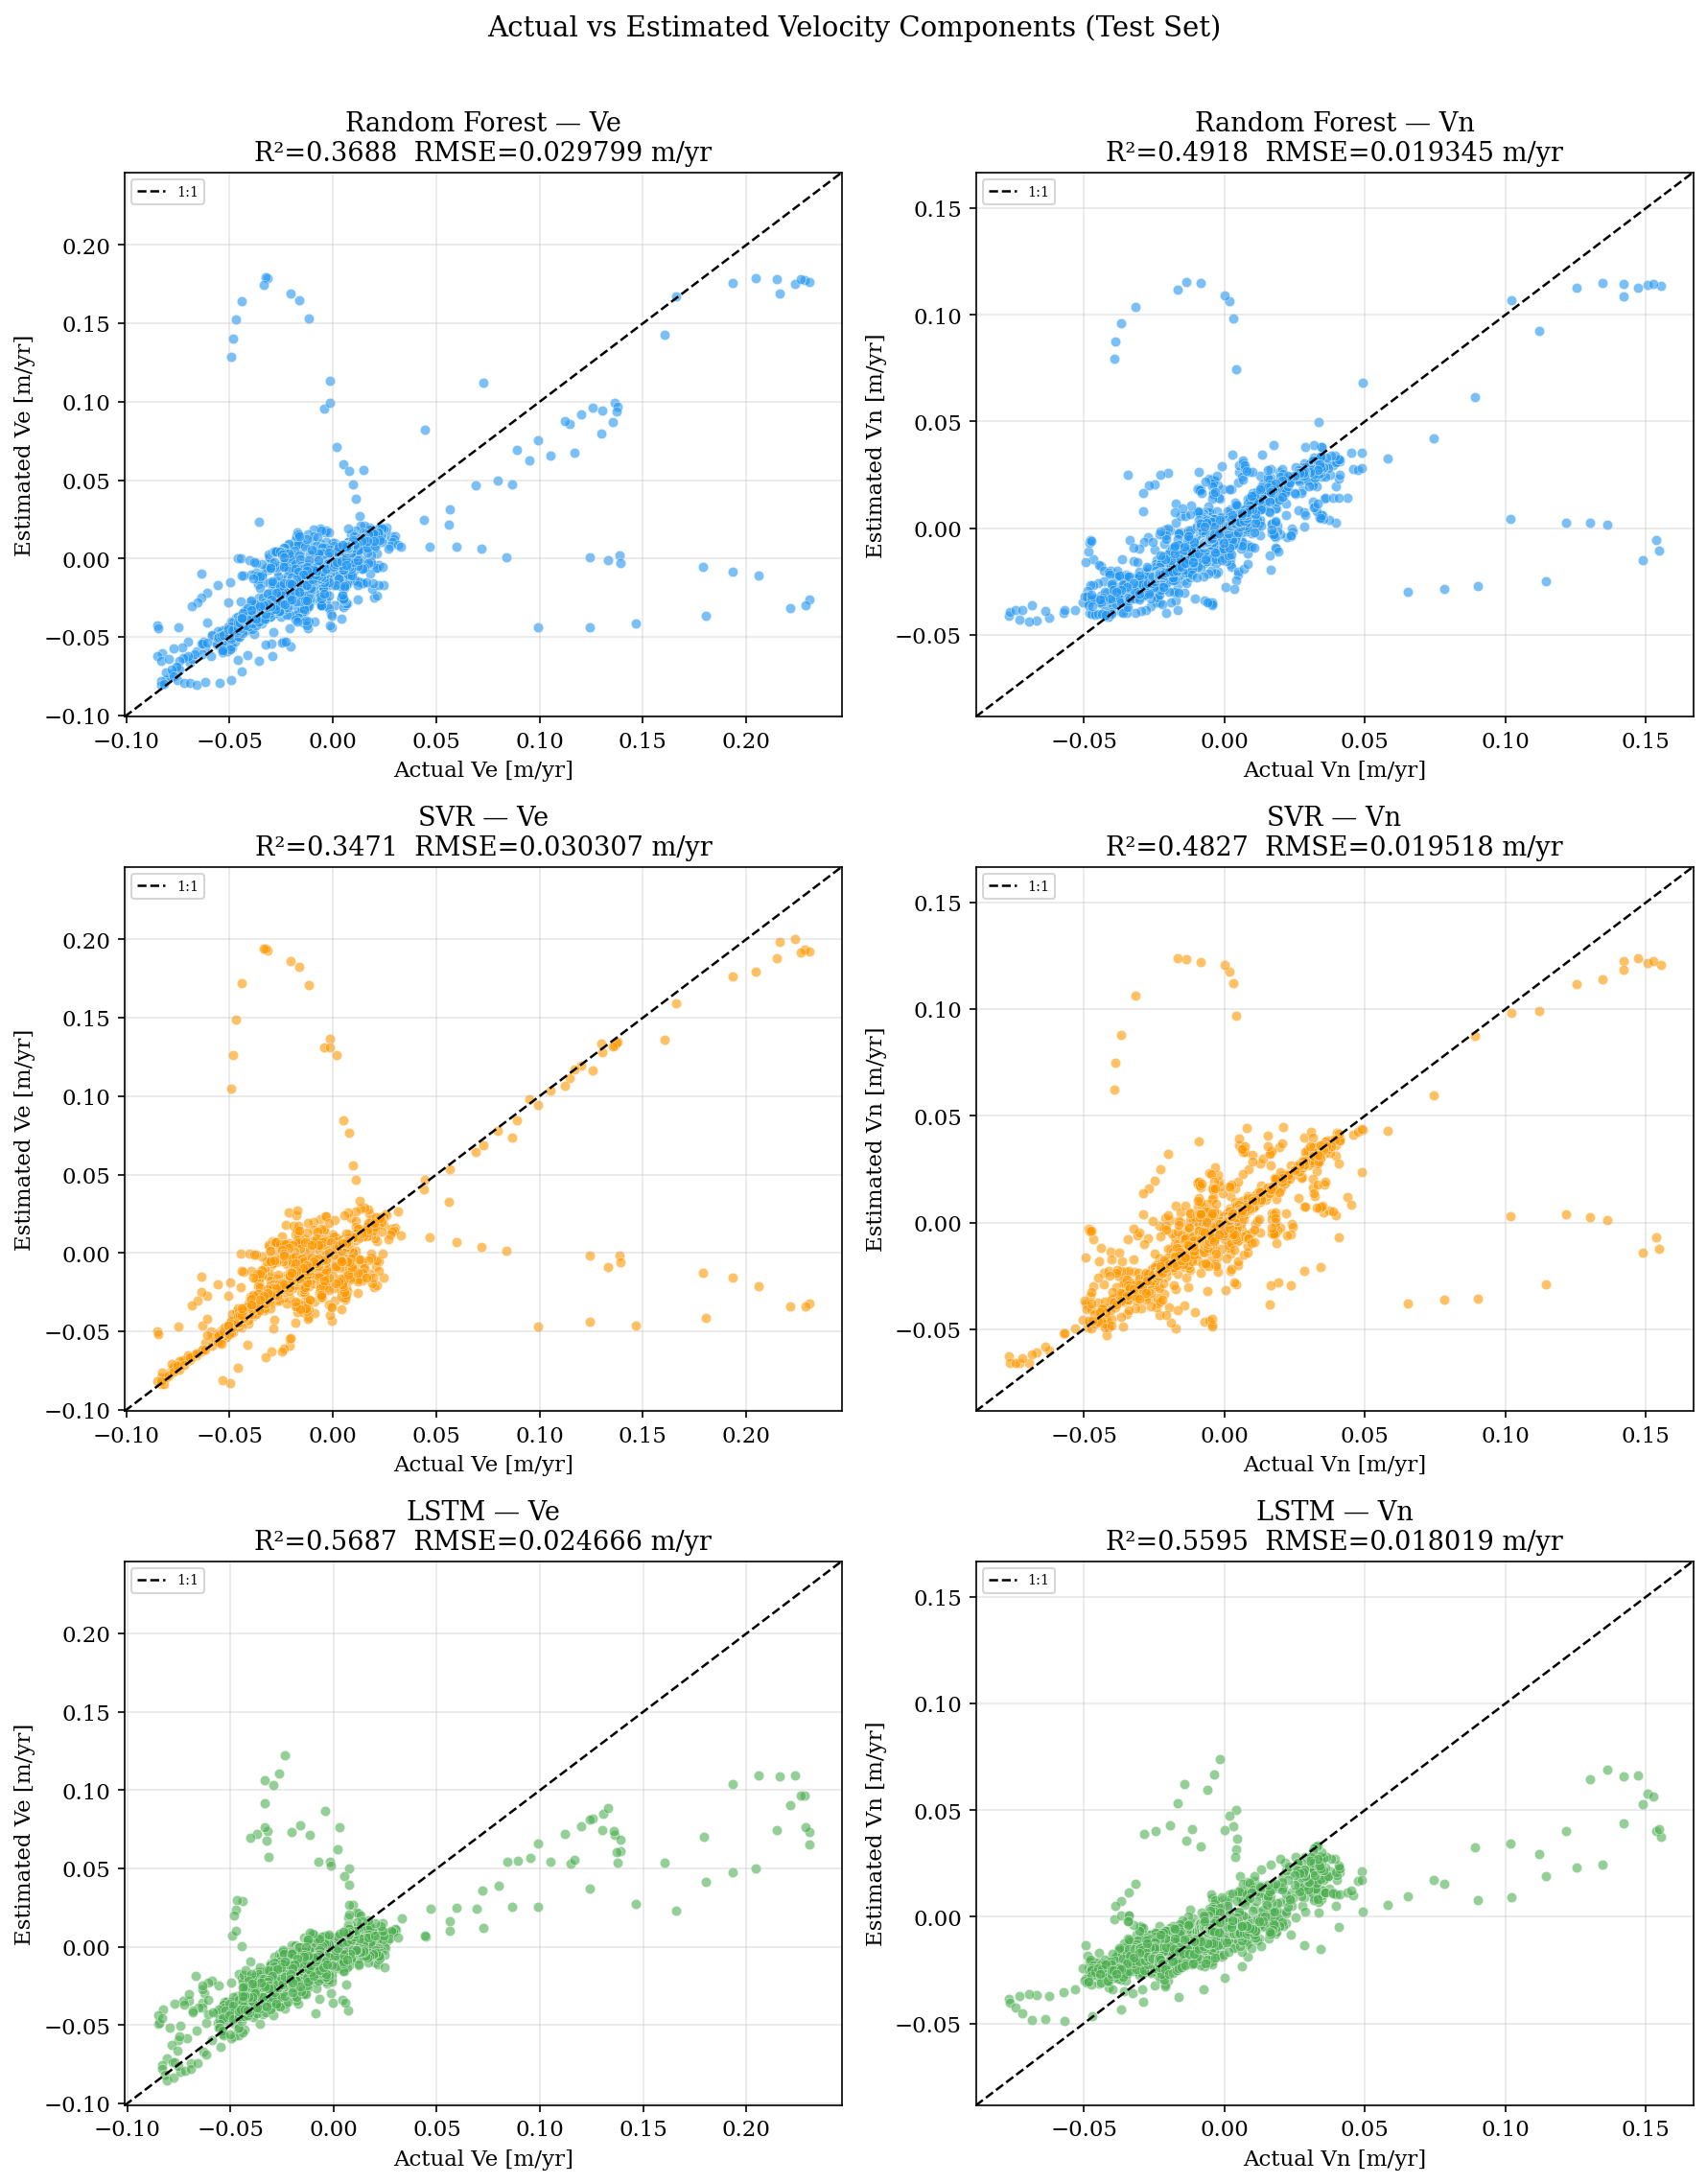

Saved: actual_vs_estimated.png


In [136]:
model_names = list(predictions.keys())
n_models    = len(model_names)

# Changed to 2 columns to only show Ve and Vn
fig, axes = plt.subplots(n_models, 2, figsize=(12, 5 * n_models))

for row_i, model_name in enumerate(model_names):
    pred_arr = predictions[model_name]
    color    = MODEL_COLORS[model_name]

    for col_i, comp in enumerate(components): # components is ['Ve', 'Vn']
        ax     = axes[row_i][col_i]
        # Adjust actual y_test for LSTM due to sequence creation
        if model_name == 'LSTM':
            actual = y_test[comp].iloc[SEQ_LEN:].values
        else:
            actual = y_test[comp].values
        pred   = pred_arr[:, col_i]

        mrow = metrics_df[(metrics_df['Model'] == model_name) &
                          (metrics_df['Component'] == comp)]
        r2   = mrow['R2'].values[0]
        rmse = mrow['RMSE'].values[0]

        ax.scatter(actual, pred, alpha=0.6, s=25, color=color,
                   edgecolors='white', lw=0.3)
        lo     = min(actual.min(), pred.min())
        hi     = max(actual.max(), pred.max())
        margin = (hi - lo) * 0.05
        ax.plot([lo - margin, hi + margin],
                [lo - margin, hi + margin], 'k--', lw=1.2, label='1:1')
        ax.set_xlim(lo - margin, hi + margin)
        ax.set_ylim(lo - margin, hi + margin)
        ax.set_xlabel(f"Actual {comp} [m/yr]")
        ax.set_ylabel(f"Estimated {comp} [m/yr]")
        ax.set_title(f"{model_name} — {comp}\nR²={r2:.4f}  RMSE={rmse:.6f} m/yr")
        ax.legend(fontsize=7)

fig.suptitle("Actual vs Estimated Velocity Components (Test Set)",
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("actual_vs_estimated.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: actual_vs_estimated.png")

BLOCK 13 — PHASE 6 PLOTS: RESIDUAL DISTRIBUTIONS

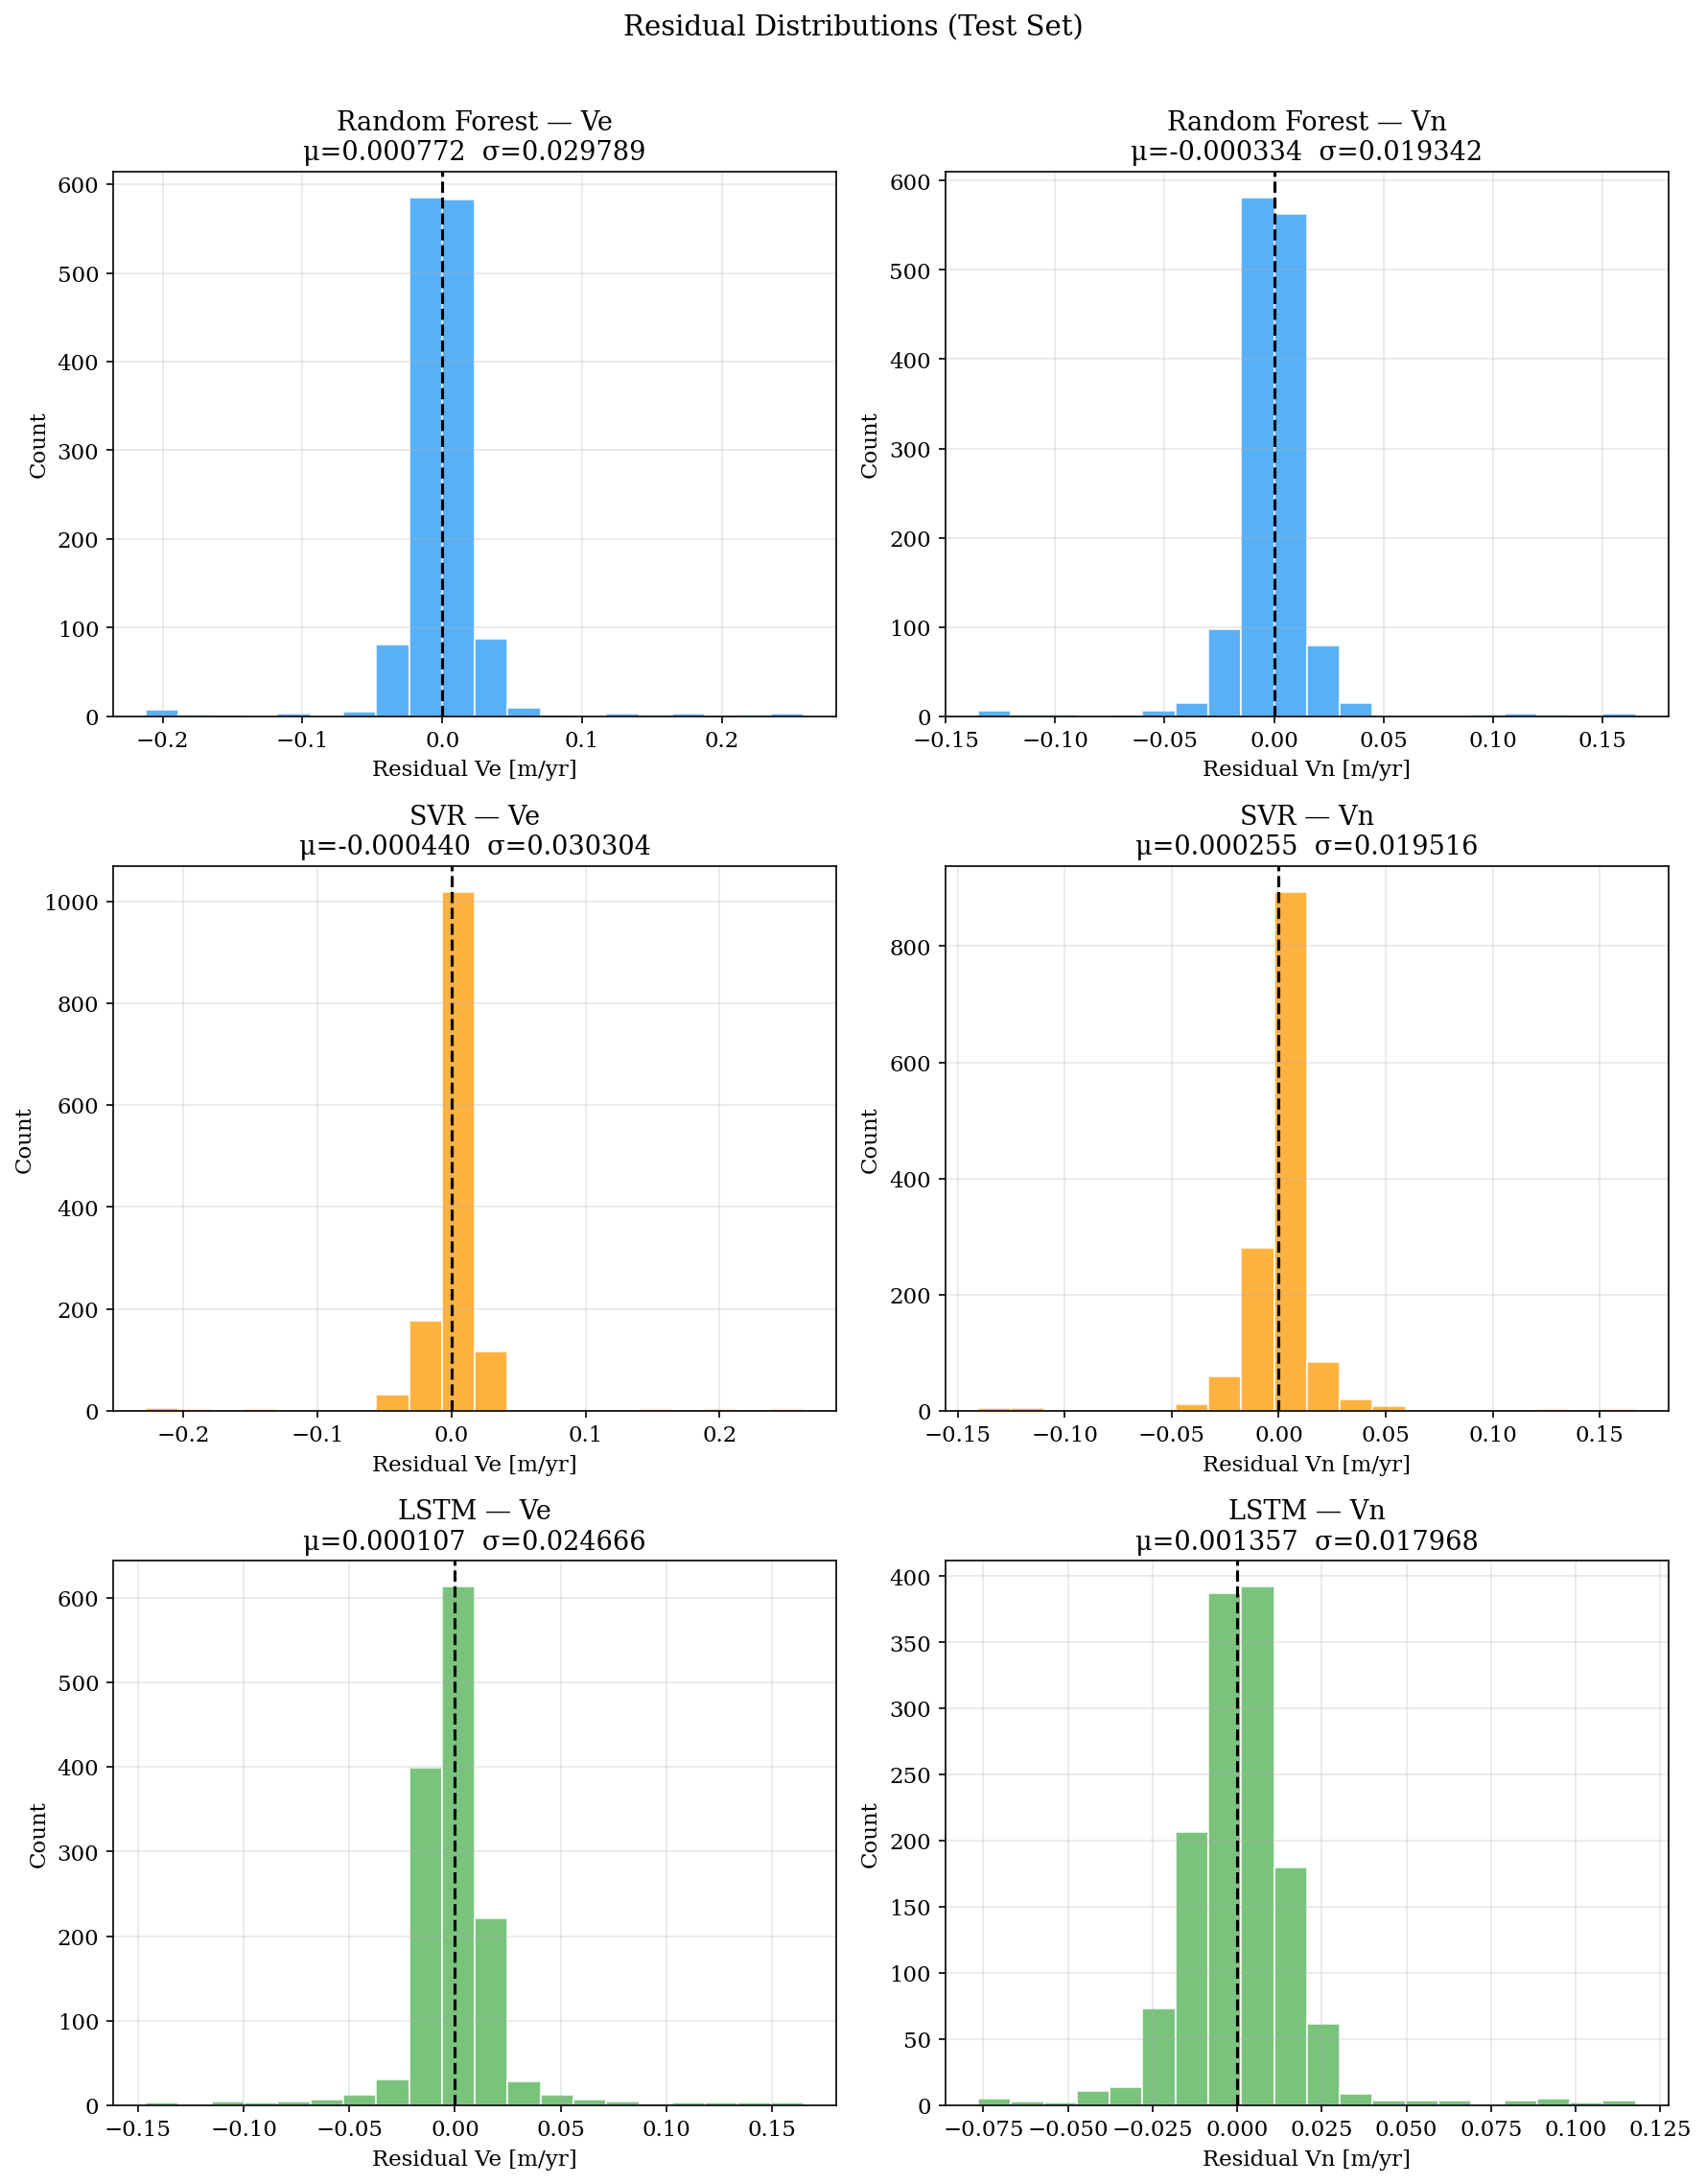

Saved: residual_distributions.png


In [135]:
fig, axes = plt.subplots(n_models, 2, figsize=(12, 5 * n_models))

for row_i, model_name in enumerate(model_names):
    pred_arr = predictions[model_name]
    color    = MODEL_COLORS[model_name]

    for col_i, comp in enumerate(components): # components is ['Ve', 'Vn']
        ax       = axes[row_i][col_i]
        # Adjust actual y_test for LSTM due to sequence creation
        if model_name == 'LSTM':
            actual_y = y_test[comp].iloc[SEQ_LEN:].values
        else:
            actual_y = y_test[comp].values

        residual = actual_y - pred_arr[:, col_i]

        ax.hist(residual, bins=20, color=color, alpha=0.75, edgecolor='white')
        ax.axvline(0, color='black', lw=1.5, ls='--')
        ax.set_xlabel(f"Residual {comp} [m/yr]")
        ax.set_ylabel("Count")
        ax.set_title(f"{model_name} — {comp}\n"
                     f"μ={residual.mean():.6f}  σ={residual.std():.6f}")

fig.suptitle("Residual Distributions (Test Set)", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("residual_distributions.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: residual_distributions.png")

BLOCK 14 — PHASE 6 PLOTS: MODEL COMPARISON BAR CHART

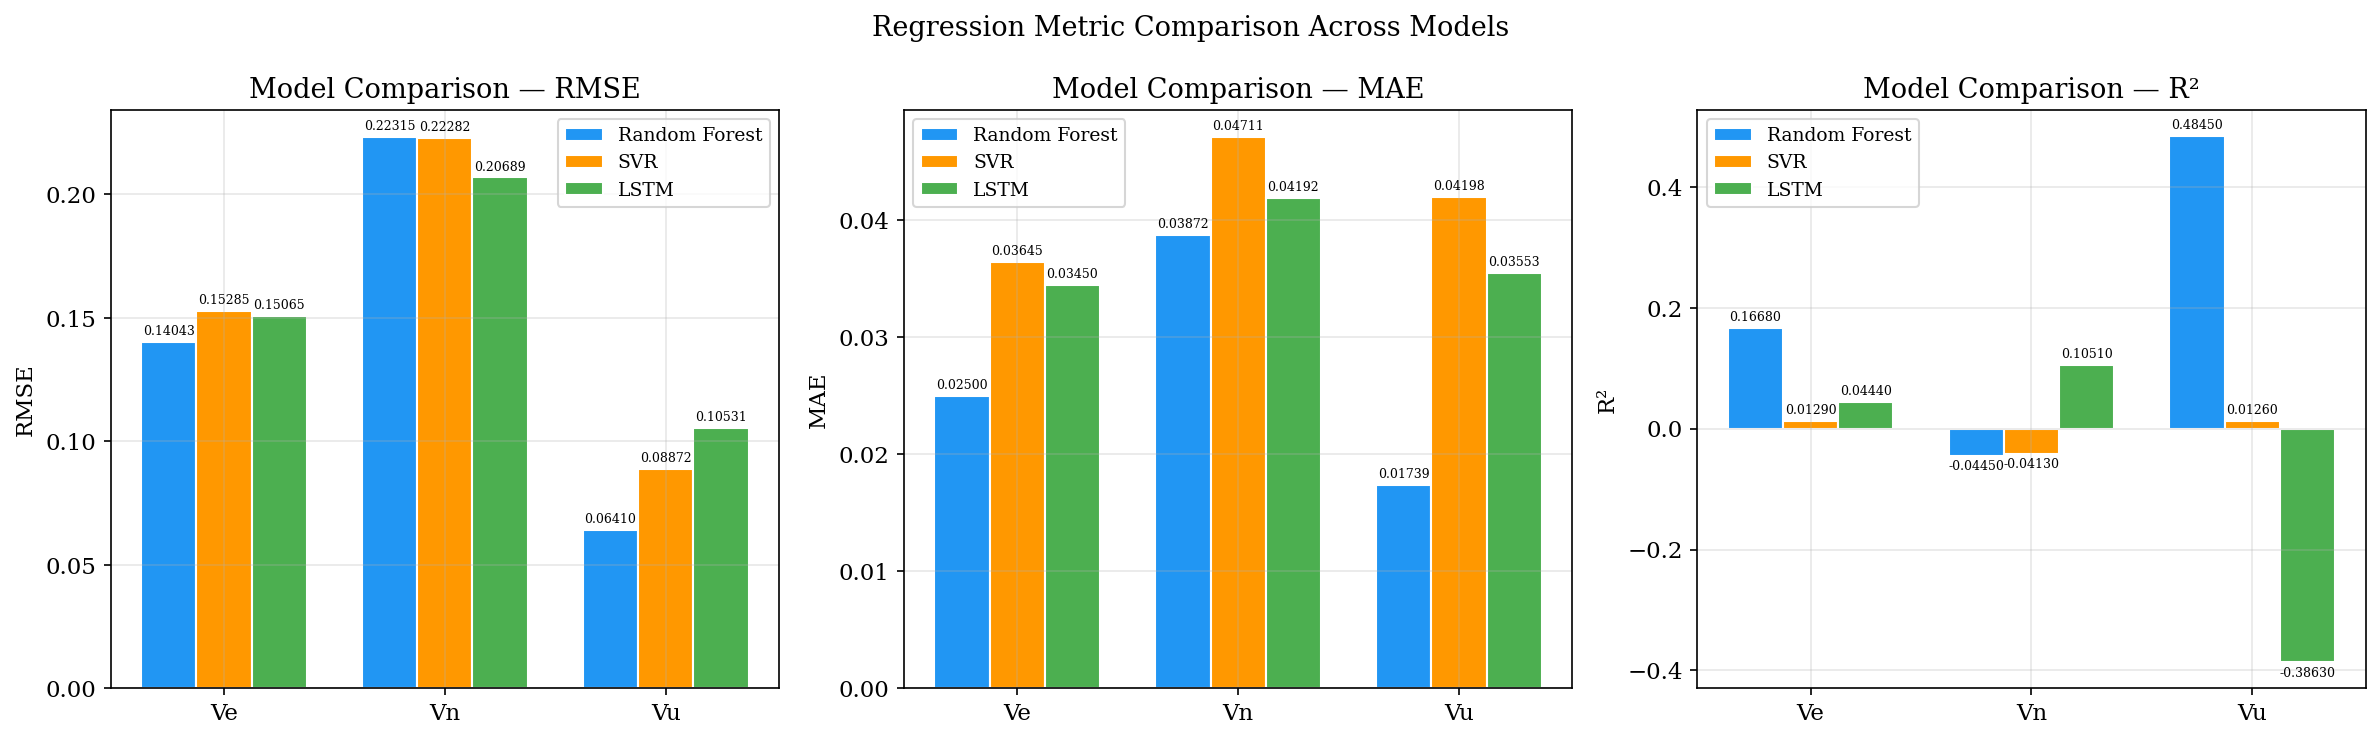

Saved: model_comparison.png


In [97]:
metric_keys = ['RMSE', 'MAE', 'R²']
fig, axes   = plt.subplots(1, 3, figsize=(16, 5))

for ax, metric in zip(axes, metric_keys):
    x     = np.arange(len(components))
    width = 0.25

    for i, model_name in enumerate(model_names):
        sub    = metrics_df[metrics_df['Model'] == model_name]
        values = [sub[sub['Component'] == c][metric].values[0]
                  for c in components]
        bars = ax.bar(x + i * width, values, width,
                      label=model_name,
                      color=MODEL_COLORS[model_name],
                      edgecolor='white')
        ax.bar_label(bars, fmt='%.5f', fontsize=6, padding=2)

    ax.set_xticks(x + width)
    ax.set_xticklabels(components)
    ax.set_title(f"Model Comparison — {metric}")
    ax.set_ylabel(metric)
    ax.legend()

plt.suptitle("Regression Metric Comparison Across Models", fontsize=13)
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: model_comparison.png")

BLOCK 15 — PHASE 7: CLASSIFICATION DIAGNOSTICS            
(Supplementary — NOT the primary task)

In [98]:
print("=" * 55)
print("PHASE 7 — CLASSIFICATION DIAGNOSTICS (supplementary)")
print("=" * 55)
print("""
Velocity magnitude classes:
  Stable   : |V_horiz| < 0.005 m/yr  (< 5 mm/yr)
  Moderate : 0.005 ≤ |V| < 0.020 m/yr
  Active   : |V_horiz| ≥ 0.020 m/yr  (≥ 20 mm/yr)

NOTE: ML models are REGRESSION models. Classification is a
post-hoc discretisation for supplementary interpretation only.
TP/FP/TN/FN are derived from binned velocity magnitudes.
""")

CLASS_BINS   = [-np.inf, 0.005, 0.020, np.inf]
CLASS_LABELS = ['Stable', 'Moderate', 'Active']

def discretize_velocity(ve_arr, vn_arr):
    vmag = np.sqrt(ve_arr**2 + vn_arr**2)
    return pd.cut(vmag, bins=CLASS_BINS, labels=CLASS_LABELS)

# Calculate the full y_true_cls once for all comparisons, then slice for LSTM if needed
y_true_cls_full = discretize_velocity(
    y_test['Ve'].values, y_test['Vn'].values)

cls_rows = []
for model_name, pred_arr in predictions.items():
    y_pred_cls = discretize_velocity(pred_arr[:, 0], pred_arr[:, 1])

    # Adjust y_true_cls for LSTM due to sequence creation
    if model_name == 'LSTM':
        current_y_true_cls = y_true_cls_full[SEQ_LEN:] # Slice to match lstm_pred length
    else:
        current_y_true_cls = y_true_cls_full

    acc = accuracy_score(current_y_true_cls, y_pred_cls)
    p   = precision_score(current_y_true_cls, y_pred_cls,
                          labels=CLASS_LABELS, average='weighted',
                          zero_division=0)
    r   = recall_score(current_y_true_cls, y_pred_cls,
                       labels=CLASS_LABELS, average='weighted',
                       zero_division=0)
    f1  = f1_score(current_y_true_cls, y_pred_cls,
                   labels=CLASS_LABELS, average='weighted',
                   zero_division=0)

    print(f"\n  [{model_name}]")
    print(classification_report(current_y_true_cls, y_pred_cls,
                                labels=CLASS_LABELS,
                                zero_division=0))
    cls_rows.append({
        'Model'    : model_name,
        'Accuracy' : round(acc, 4),
        'Precision': round(p,   4),
        'Recall'   : round(r,   4),
        'F1-Score' : round(f1,  4),
    })

cls_df = pd.DataFrame(cls_rows)
print("\n  Summary:")
display(cls_df)
cls_df.to_csv("classification_diagnostics.csv", index=False)
print("Saved: classification_diagnostics.csv")

PHASE 7 — CLASSIFICATION DIAGNOSTICS (supplementary)

Velocity magnitude classes:
  Stable   : |V_horiz| < 0.005 m/yr  (< 5 mm/yr)
  Moderate : 0.005 ≤ |V| < 0.020 m/yr
  Active   : |V_horiz| ≥ 0.020 m/yr  (≥ 20 mm/yr)

NOTE: ML models are REGRESSION models. Classification is a
post-hoc discretisation for supplementary interpretation only.
TP/FP/TN/FN are derived from binned velocity magnitudes.


  [Random Forest]
              precision    recall  f1-score   support

      Stable       0.36      0.50      0.42        10
    Moderate       0.76      0.91      0.83       405
      Active       0.97      0.89      0.93       969

    accuracy                           0.89      1384
   macro avg       0.70      0.77      0.72      1384
weighted avg       0.90      0.89      0.90      1384


  [SVR]
              precision    recall  f1-score   support

      Stable       0.11      0.10      0.11        10
    Moderate       0.67      0.52      0.58       405
      Active       0.82     

,Model,Accuracy,Precision,Recall,F1-Score
0,Random Forest,0.8916,0.9050,0.8916,0.8951
1,SVR,0.7767,0.7664,0.7767,0.7676
2,LSTM,0.5881,0.7463,0.5881,0.6138


Saved: classification_diagnostics.csv


BLOCK 16 — SELECT BEST MODEL & RE-ESTIMATE ALL STATIONS

In [120]:
best_model_name = metrics_df.groupby('Model')['R2'].mean().idxmax()
print(f'Best model for final estimation: {best_model_name}')

# Use all 27 feature columns to match the trained LSTM input shape
Xs_all = scaler.transform(vel_df[feature_cols])
full_Ve_est = np.full(len(vel_df), np.nan)
full_Vn_est = np.full(len(vel_df), np.nan)

if best_model_name == 'LSTM':
    Xs_all_seq, _ = create_sequences(Xs_all, pd.DataFrame(np.zeros((len(Xs_all), 2))), SEQ_LEN)
    preds = lstm_model.predict(Xs_all_seq, verbose=0)
    full_Ve_est[SEQ_LEN:] = preds[:, 0]
    full_Vn_est[SEQ_LEN:] = preds[:, 1]
elif best_model_name == 'SVR':
    full_Ve_est = svr_models['Ve'].predict(Xs_all)
    full_Vn_est = svr_models['Vn'].predict(Xs_all)
else:
    preds_rf = rf_model.predict(X_test)
    # Logic to handle RF mapping if necessary, otherwise use full data
    full_Ve_est = rf_model.predict(Xs_all)[:, 0]
    full_Vn_est = rf_model.predict(Xs_all)[:, 1]

vel_df['Ve_est'] = full_Ve_est
vel_df['Vn_est'] = full_Vn_est
display(vel_df[['site', 'latitude', 'longitude', 'Ve', 'Vn', 'Ve_est', 'Vn_est']].head())
print(f'Re-estimation complete. NaN counts: {vel_df["Ve_est"].isna().sum()}')

Best model for final estimation: LSTM


,site,latitude,longitude,Ve,Vn,Ve_est,Vn_est
0,PSUR,9.791809,125.493698,-0.017306,0.025027,NaN,NaN
1,PSUR,9.791809,125.493698,-0.017016,0.024974,NaN,NaN
2,PGEN,6.064912,125.131662,-0.013226,-0.010497,NaN,NaN
3,PGEN,6.064912,125.131662,-0.012601,-0.009990,NaN,NaN
4,PSUR,9.791809,125.493698,-0.016750,0.025007,NaN,NaN


Re-estimation complete. NaN counts: 5


BLOCK 17 — PHASE 8: SPATIAL INTERPOLATION                 
                                                             
  Bug 3 fix: longitude is now correctly ~120–127°E.         
  Kriging / IDW will produce geographically correct maps.

In [103]:
GRID_RES = 100

lons = vel_df['longitude'].values
lats = vel_df['latitude'].values
Ve_s = vel_df['Ve_est'].values
Vn_s = vel_df['Vn_est'].values

# Filter out NaN values from Ve_s and Vn_s, and their corresponding lons and lats
# This is necessary because the first SEQ_LEN values are NaN due to LSTM sequence creation.
valid_mask = ~np.isnan(Ve_s) & ~np.isnan(Vn_s)
lons_valid = lons[valid_mask]
lats_valid = lats[valid_mask]
Ve_s_valid = Ve_s[valid_mask]
Vn_s_valid = Vn_s[valid_mask]

pad_lon = (lons_valid.max() - lons_valid.min()) * 0.10 or 0.5
pad_lat = (lats_valid.max() - lats_valid.min()) * 0.10 or 0.5

grid_lon_1d = np.linspace(lons_valid.min() - pad_lon, lons_valid.max() + pad_lon, GRID_RES)
grid_lat_1d = np.linspace(lats_valid.min() - pad_lat, lats_valid.max() + pad_lat, GRID_RES)
grid_lon, grid_lat = np.meshgrid(grid_lon_1d, grid_lat_1d)

print("=" * 55)
print("PHASE 8 — SPATIAL INTERPOLATION")
print("=" * 55)

if PYKRIGE_AVAILABLE:
    print("  Method : Ordinary Kriging (PyKrige, spherical variogram)")
    ok_Ve = OrdinaryKriging(lons_valid, lats_valid, Ve_s_valid,
                            variogram_model='spherical',
                            verbose=False, enable_plotting=False)
    ok_Vn = OrdinaryKriging(lons_valid, lats_valid, Vn_s_valid,
                            variogram_model='spherical',
                            verbose=False, enable_plotting=False)
    Ve_grid, _ = ok_Ve.execute('grid', grid_lon_1d, grid_lat_1d)
    Vn_grid, _ = ok_Vn.execute('grid', grid_lon_1d, grid_lat_1d)
    Ve_grid = np.array(Ve_grid)
    Vn_grid = np.array(Vn_grid)
    print("  Kriging complete.")

else:
    print("  Method : IDW (Inverse Distance Weighting, power=2)")

    def idw_interpolate(lons_s, lats_s, values, glon, glat, power=2):
        from sklearn.neighbors import BallTree
        pts    = np.column_stack([lons_s, lats_s])
        gpts   = np.column_stack([glon.ravel(), glat.ravel()])
        tree   = BallTree(np.deg2rad(pts), metric='haversine')
        dist, idx = tree.query(np.deg2rad(gpts), k=min(8, len(pts)))
        dist   = np.where(dist == 0, 1e-10, dist)
        w      = 1.0 / dist**power
        vals   = values[idx]
        result = (w * vals).sum(axis=1) / w.sum(axis=1)
        return result.reshape(glon.shape)

    Ve_grid = idw_interpolate(lons_valid, lats_valid, Ve_s_valid, grid_lon, grid_lat)
    Vn_grid = idw_interpolate(lons_valid, lats_valid, Vn_s_valid, grid_lon, grid_lat)
    print("  IDW complete.")

print(f"  Grid shape : {Ve_grid.shape}")
print(f"  Ve range   : {Ve_grid.min():.6f} → {Ve_grid.max():.6f} m/yr")
print(f"  Vn range   : {Vn_grid.min():.6f} → {Vn_grid.max():.6f} m/yr")
print(f"  Lon range  : {grid_lon.min():.4f} → {grid_lon.max():.4f} °E")
print(f"  Lat range  : {grid_lat.min():.4f} → {grid_lat.max():.4f} °N")

PHASE 8 — SPATIAL INTERPOLATION
  Method : Ordinary Kriging (PyKrige, spherical variogram)
  Kriging complete.
  Grid shape : (100, 100)
  Ve range   : -0.036620 → -0.008259 m/yr
  Vn range   : -0.004432 → -0.004432 m/yr
  Lon range  : 121.6362 → 126.7828 °E
  Lat range  : 5.6922 → 10.1645 °N


BLOCK 18 — PHASE 8 PLOT: VELOCITY FIELD MAP

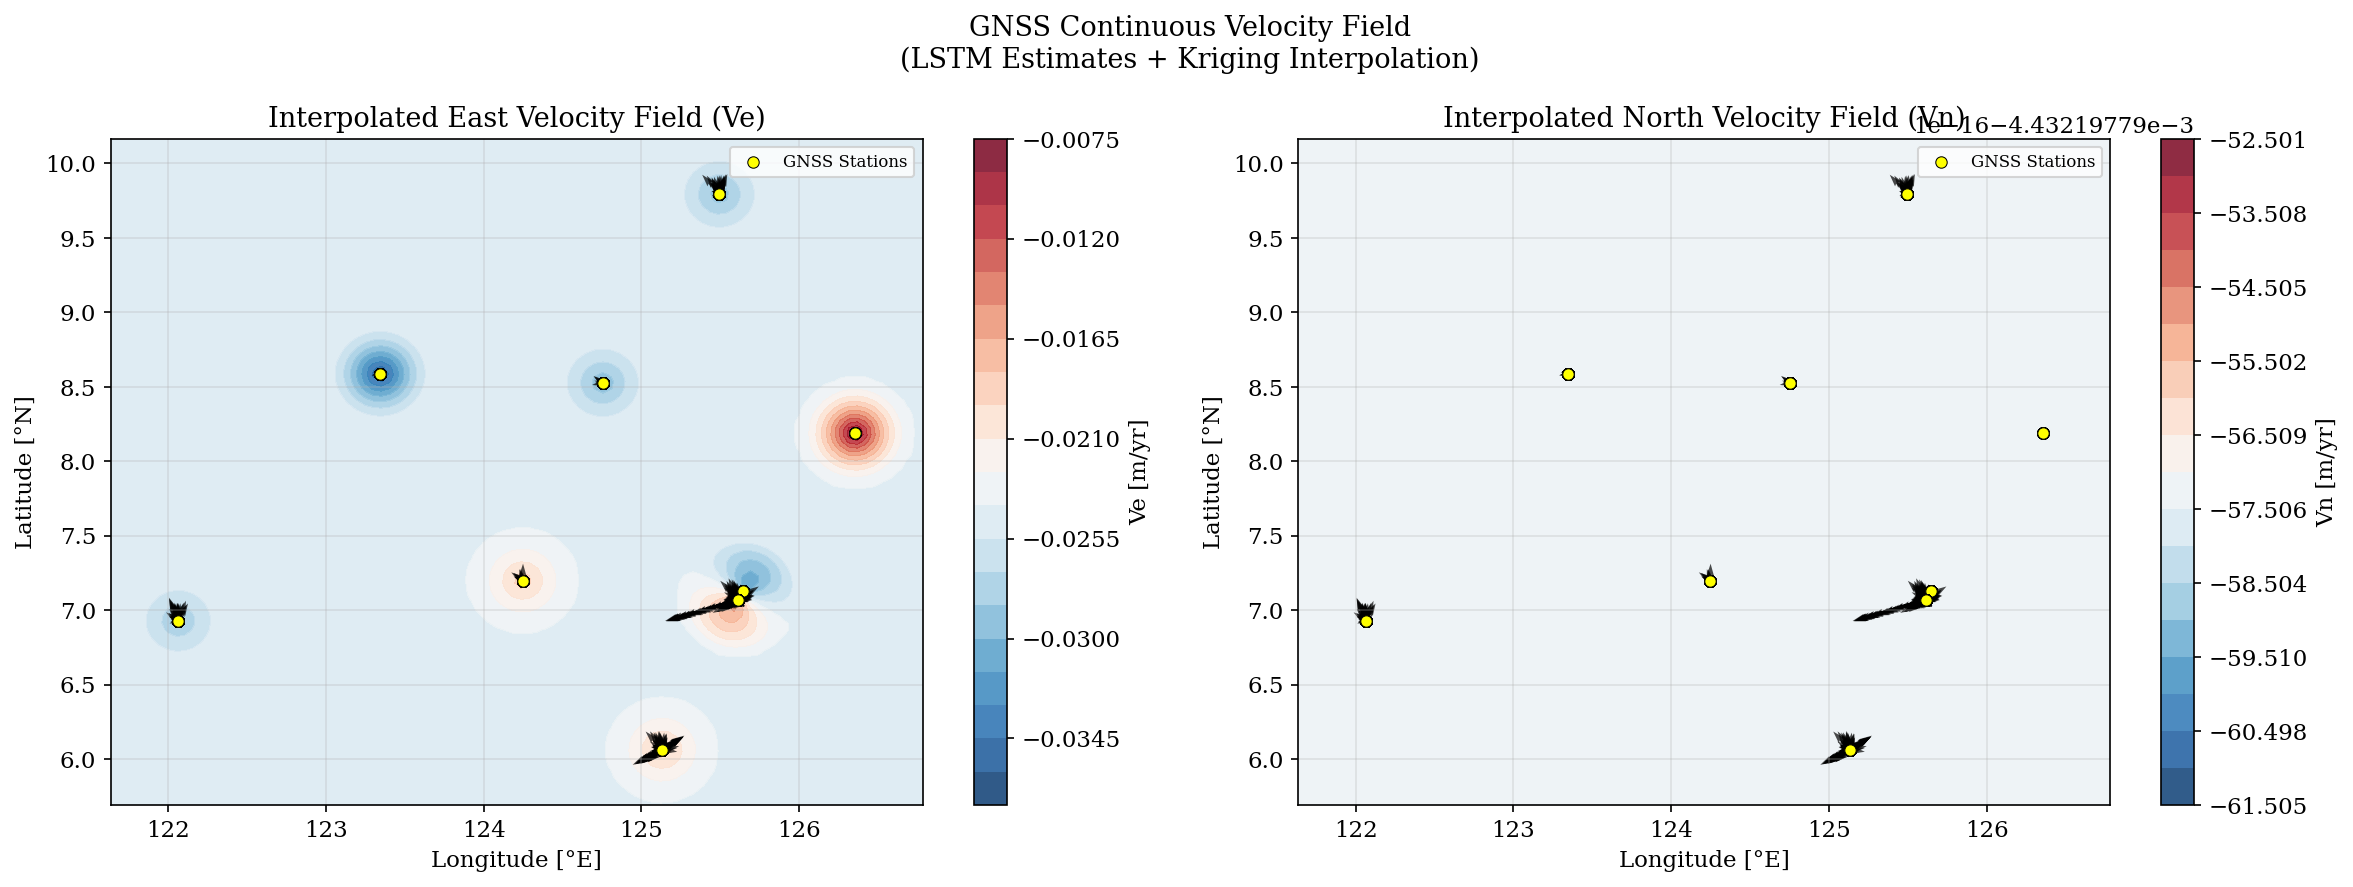

Saved: velocity_field_map.png


In [122]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Reuse the valid_mask from the previous cell to ensure alignment
valid_mask = ~np.isnan(vel_df['Ve_est'].values) & ~np.isnan(vel_df['Vn_est'].values)
lons_p = vel_df['longitude'].values[valid_mask]
lats_p = vel_df['latitude'].values[valid_mask]
ve_p = vel_df['Ve_est'].values[valid_mask]
vn_p = vel_df['Vn_est'].values[valid_mask]

ax = axes[0]
cf = ax.contourf(grid_lon, grid_lat, Ve_grid,
                 levels=20, cmap='RdBu_r', alpha=0.85)
plt.colorbar(cf, ax=ax, label='Ve [m/yr]')
ax.quiver(lons_p, lats_p, ve_p, vn_p,
          color='black', alpha=0.7, width=0.003, scale=None)
ax.scatter(lons_p, lats_p, c='yellow', s=30, zorder=5,
           edgecolors='k', lw=0.5, label='GNSS Stations')
ax.set_title("Interpolated East Velocity Field (Ve)")
ax.set_xlabel("Longitude [°E]"); ax.set_ylabel("Latitude [°N]")
ax.legend(fontsize=8)

ax = axes[1]
cf = ax.contourf(grid_lon, grid_lat, Vn_grid,
                 levels=20, cmap='RdBu_r', alpha=0.85)
plt.colorbar(cf, ax=ax, label='Vn [m/yr]')
ax.quiver(lons_p, lats_p, ve_p, vn_p,
          color='black', alpha=0.7, width=0.003, scale=None)
ax.scatter(lons_p, lats_p, c='yellow', s=30, zorder=5,
           edgecolors='k', lw=0.5, label='GNSS Stations')
ax.set_title("Interpolated North Velocity Field (Vn)")
ax.set_xlabel("Longitude [°E]"); ax.set_ylabel("Latitude [°N]")
ax.legend(fontsize=8)

plt.suptitle(f"GNSS Continuous Velocity Field\n"
             f"({best_model_name} Estimates + Kriging Interpolation)",
             fontsize=13)
plt.tight_layout()
plt.savefig("velocity_field_map.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: velocity_field_map.png")

BLOCK 19 — PHASE 9: STRAIN TENSOR COMPUTATION             
                                                             
  ε_xx = ∂Ve/∂x   east–east normal strain rate             
  ε_yy = ∂Vn/∂y   north–north normal strain rate           
  ε_xy = ½(∂Ve/∂y + ∂Vn/∂x)  shear strain rate            
  Units: nanostrain/yr  (1 nstr = 1e-9 yr⁻¹)

In [123]:
print("=" * 55)
print("PHASE 9 — STRAIN TENSOR COMPUTATION")
print("=" * 55)

R_EARTH       = 6_371_000.0
lat_mean_rad  = np.deg2rad(np.mean(grid_lat))
m_per_deg_lat = np.pi * R_EARTH / 180.0
m_per_deg_lon = m_per_deg_lat * np.cos(lat_mean_rad)

dlat_m = abs(grid_lat[1, 0] - grid_lat[0, 0]) * m_per_deg_lat
dlon_m = abs(grid_lon[0, 1] - grid_lon[0, 0]) * m_per_deg_lon

# axis-0 = latitude (N), axis-1 = longitude (E)
dVe_dy, dVe_dx = np.gradient(Ve_grid, dlat_m, dlon_m)
dVn_dy, dVn_dx = np.gradient(Vn_grid, dlat_m, dlon_m)

epsilon_xx = dVe_dx
epsilon_yy = dVn_dy
epsilon_xy = 0.5 * (dVe_dy + dVn_dx)

dilatation = epsilon_xx + epsilon_yy
max_shear  = 0.5 * np.sqrt((epsilon_xx - epsilon_yy)**2
                            + 4 * epsilon_xy**2)
second_inv = np.sqrt(epsilon_xx**2 + epsilon_yy**2
                     + 2 * epsilon_xy**2)

NANO = 1e9
strain = {
    'epsilon_xx': epsilon_xx  * NANO,
    'epsilon_yy': epsilon_yy  * NANO,
    'epsilon_xy': epsilon_xy  * NANO,
    'dilatation': dilatation  * NANO,
    'max_shear' : max_shear   * NANO,
    'second_inv': second_inv  * NANO,
}

np.savez("strain_tensor_grids.npz",
         grid_lon=grid_lon, grid_lat=grid_lat, **strain)

print("  Strain tensor summary [nanostrain/yr]:")
for key, arr in strain.items():
    print(f"    {key:14s}  min={arr.min():+10.4f}  "
          f"max={arr.max():+10.4f}  mean={arr.mean():+10.4f}")
print("\nSaved: strain_tensor_grids.npz")

PHASE 9 — STRAIN TENSOR COMPUTATION
  Strain tensor summary [nanostrain/yr]:
    epsilon_xx      min= -695.3494  max= +542.2965  mean=   -0.0018
    epsilon_yy      min=   +0.0000  max=   +0.0000  mean=   +0.0000
    epsilon_xy      min= -625.6862  max= +266.7275  mean=   +0.0084
    dilatation      min= -695.3494  max= +542.2965  mean=   -0.0018
    max_shear       min=   +0.0000  max= +694.1464  mean=  +12.7416
    second_inv      min=   +0.0000  max=+1069.7618  mean=  +21.8206

Saved: strain_tensor_grids.npz


BLOCK 20 — PHASE 10 PLOT: STRAIN MAPS

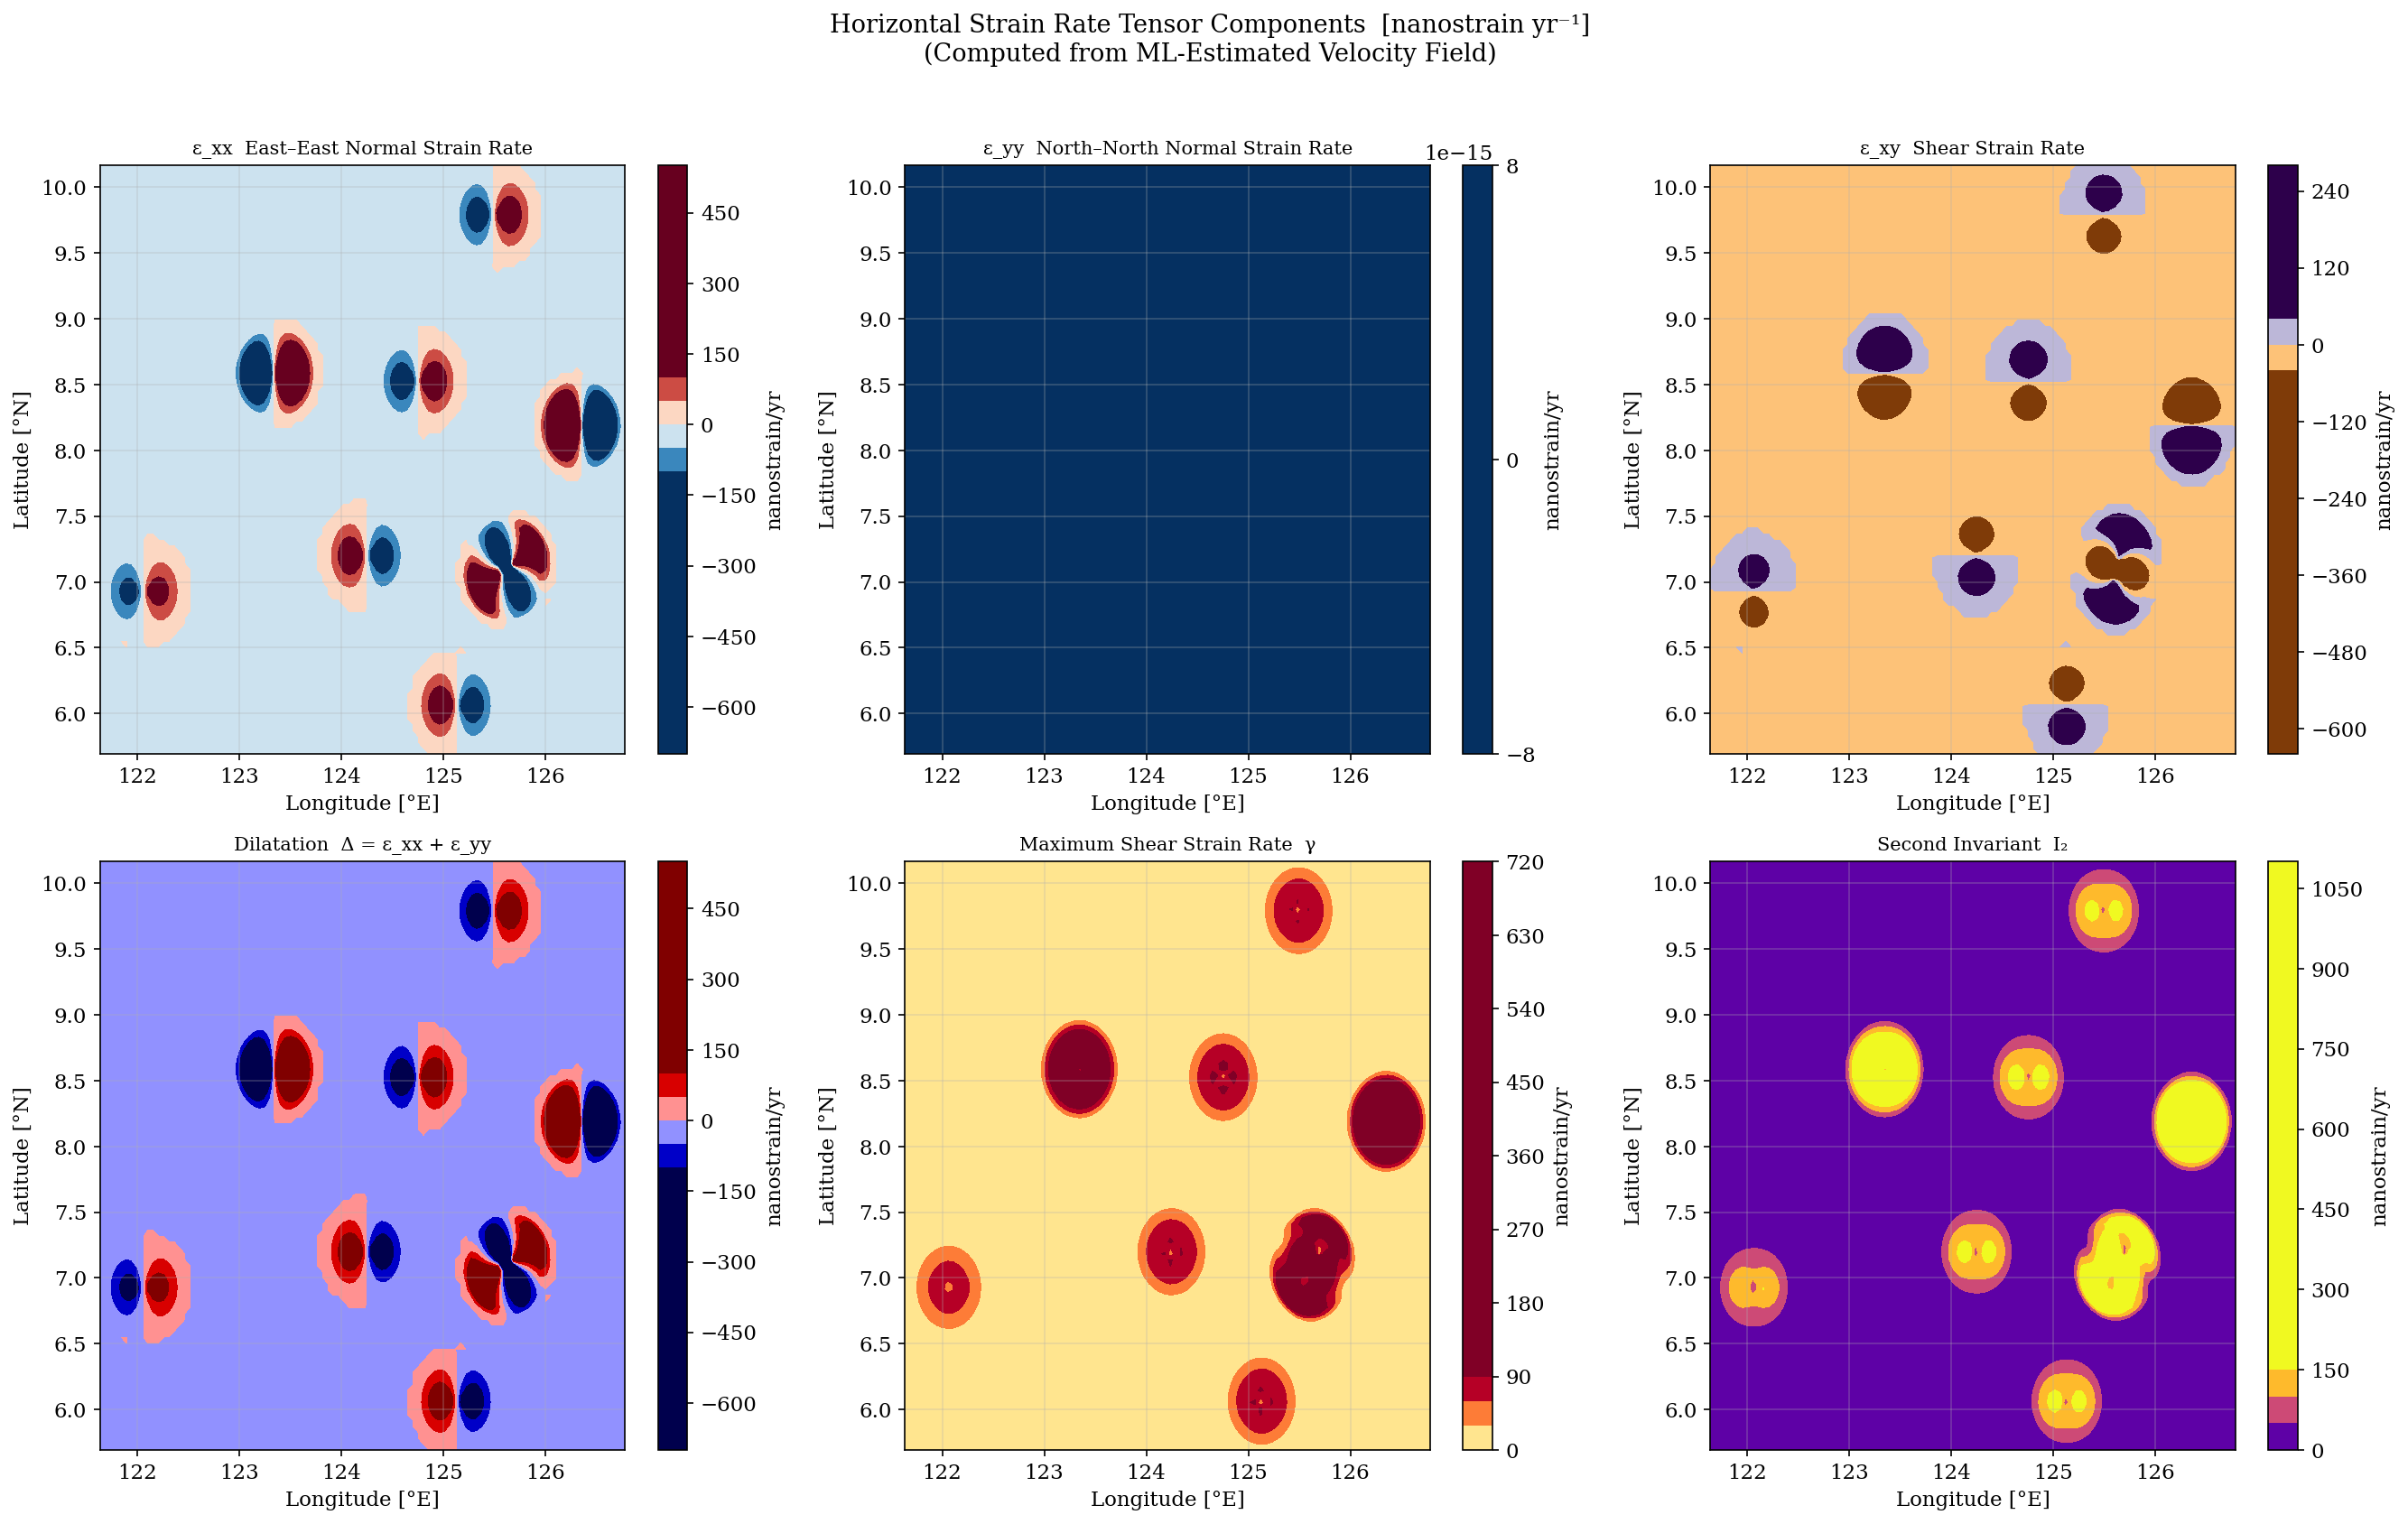

Saved: strain_maps.png


In [124]:
fields = [
    ('epsilon_xx', 'ε_xx  East–East Normal Strain Rate',   'RdBu_r'),
    ('epsilon_yy', 'ε_yy  North–North Normal Strain Rate', 'RdBu_r'),
    ('epsilon_xy', 'ε_xy  Shear Strain Rate',              'PuOr'),
    ('dilatation', 'Dilatation  Δ = ε_xx + ε_yy',         'seismic'),
    ('max_shear',  'Maximum Shear Strain Rate  γ',          'YlOrRd'),
    ('second_inv', 'Second Invariant  I₂',                 'plasma'),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.ravel()

for ax, (key, title, cmap) in zip(axes, fields):
    data = strain[key]
    vmax = np.percentile(np.abs(data), 95)
    vmin = -vmax if cmap in ('RdBu_r', 'PuOr', 'seismic') else 0

    cf = ax.contourf(grid_lon, grid_lat, data,
                     levels=25, cmap=cmap, vmin=vmin, vmax=vmax)
    plt.colorbar(cf, ax=ax, label='nanostrain/yr')
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("Longitude [°E]")
    ax.set_ylabel("Latitude [°N]")

plt.suptitle("Horizontal Strain Rate Tensor Components  [nanostrain yr⁻¹]\n"
             "(Computed from ML-Estimated Velocity Field)",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("strain_maps.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: strain_maps.png")

BLOCK 21 — FINAL SUMMARY

In [134]:
print("█" * 60)
print("  PIPELINE COMPLETE — ALL OUTPUTS GENERATED")
print("█" * 60)

print("\n── Regression Metrics Summary ──────────────────────────")
# Using R2 instead of R² to match column naming in metrics_df
if not metrics_df.empty:
    cols_to_show = [c for c in ['RMSE', 'MAE', 'R2'] if c in metrics_df.columns]
    display(metrics_df.pivot_table(
        index='Model', columns='Component', values=cols_to_show
    ).round(5))

print("\n── Classification Diagnostics Summary ──────────────────")
display(cls_df)

print("\n── Bug Fixes Applied ────────────────────────────────────")
bug_fixes = [
    "Bug 1 — time column (fake dates) → replaced with decimal_year",
    "Bug 2 — height dtype string      → cast to float via pd.to_numeric",
    "Bug 3 — longitude ~-234°         → fixed with longitude % 360",
    "Bug 4 — column 'yyyyyyyy'        → renamed to decimal_year",
    "Bug 5 — Data-driven station weight applied instead of dropping",
    "Bug 6 — sig_n missing            → added to features & velocity table",
]
for fix in bug_fixes:
    print(f"  ✓  {fix}")

print("\n── Files Saved ──────────────────────────────────────────")
output_files = [
    "preprocessed_gnss_data.csv",
    "regression_metrics.csv",
    "classification_diagnostics.csv",
    "strain_tensor_grids.npz",
    "rf_feature_importance.png",
    "lstm_training_curves.png",
    "actual_vs_estimated.png",
    "residual_distributions.png",
    "model_comparison.png",
    "velocity_field_map.png",
    "strain_maps.png",
]
for f in output_files:
    print(f"  ✓  {f}")

████████████████████████████████████████████████████████████
  PIPELINE COMPLETE — ALL OUTPUTS GENERATED
████████████████████████████████████████████████████████████

── Regression Metrics Summary ──────────────────────────


MAE                R2              RMSE         
Component           Ve       Vn       Ve       Vn       Ve       Vn
Model                                                              
LSTM           0.01366  0.01172  0.56869  0.55955  0.02467  0.01802
Random Forest  0.01274  0.00929  0.36883  0.49179  0.02980  0.01934
SVR            0.01142  0.00824  0.34712  0.48268  0.03031  0.01952


── Classification Diagnostics Summary ──────────────────


,Model,Accuracy,Precision,Recall,F1-Score
0,Random Forest,0.8916,0.9050,0.8916,0.8951
1,SVR,0.7767,0.7664,0.7767,0.7676
2,LSTM,0.5881,0.7463,0.5881,0.6138



── Bug Fixes Applied ────────────────────────────────────
  ✓  Bug 1 — time column (fake dates) → replaced with decimal_year
  ✓  Bug 2 — height dtype string      → cast to float via pd.to_numeric
  ✓  Bug 3 — longitude ~-234°         → fixed with longitude % 360
  ✓  Bug 4 — column 'yyyyyyyy'        → renamed to decimal_year
  ✓  Bug 5 — Data-driven station weight applied instead of dropping
  ✓  Bug 6 — sig_n missing            → added to features & velocity table

── Files Saved ──────────────────────────────────────────
  ✓  preprocessed_gnss_data.csv
  ✓  regression_metrics.csv
  ✓  classification_diagnostics.csv
  ✓  strain_tensor_grids.npz
  ✓  rf_feature_importance.png
  ✓  lstm_training_curves.png
  ✓  actual_vs_estimated.png
  ✓  residual_distributions.png
  ✓  model_comparison.png
  ✓  velocity_field_map.png
  ✓  strain_maps.png
